# Ejercicio 10. La variable de negatividad y el reentrenamiento

El enunciado pide crear una variable con la negatividad de cada tweet, incluirla en el conjunto
de datos, entrenar de nuevo el clasificador y responder si la inclusión mejoró los resultados
y, en caso afirmativo, en qué medida.

La segunda mitad de esa pregunta es la difícil. Para decir *en qué medida* mejoró hace falta
que la comparación pueda distinguir una mejora real del ruido de la partición, y una sola
división 80/20 no lo permite: la diferencia entre dos modelos sobre 1,523 tweets de validación
puede cambiar de signo con sólo mover la semilla. Aquí se compara de tres formas —la partición
fija del ejercicio 6, validación cruzada repetida, y una prueba pareada sobre las mismas
predicciones— y se exige que las tres coincidan antes de afirmar nada.

**Definición.** La negatividad es la puntuación compuesta de VADER invertida y reescalada:

$$\text{negatividad} = \frac{1 - \text{compound}}{2} \in [0, 1]$$

Vale 0 en el tweet más positivo posible y 1 en el más negativo. Se deja sin valores negativos a
propósito, porque el mejor modelo del ejercicio 6 es Naive Bayes multinomial y no admite
entradas negativas.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

from src import config, modelos as mod, sentimiento as sen

warnings.filterwarnings('ignore')
config.preparar_directorios()
sns.set_theme(style='whitegrid')

df = pd.read_csv(config.PROCESADO / 'train_sentimiento.csv')
df['cleaned_text'] = df['cleaned_text'].fillna('')

print('La variable ya forma parte del conjunto guardado en processed/train_sentimiento.csv:')
print(df[['id', 'target', 'vader_compound', 'negatividad']].head(8).to_string(index=False))
print()
print(df.groupby(df['target'].map(config.ETIQUETAS))['negatividad']
        .agg(n='size', media='mean', mediana='median', desv='std').round(4).to_string())

La variable ya forma parte del conjunto guardado en processed/train_sentimiento.csv:
 id  target  vader_compound  negatividad
  1       1          0.2732      0.36340
  4       1         -0.3400      0.67000
  5       1         -0.2960      0.64800
  6       1          0.0000      0.50000
  7       1          0.0000      0.50000
  8       1         -0.3400      0.67000
 10       1         -0.6249      0.81245
 13       1         -0.1531      0.57655

                n   media  mediana    desv
target                                    
Desastre     3271  0.6332   0.6591  0.2176
No desastre  4342  0.5260   0.5000  0.2326


## 10.1 Cuánta señal lleva la variable por sí sola

Antes de añadirla a nada conviene saber cuánto vale sola. Se entrena una regresión logística
que no ve el texto: sólo la negatividad. Si su desempeño se acerca al del modelo completo, la
variable es valiosa; si apenas supera al azar, difícilmente aportará algo a un modelo que ya
lee las palabras.

In [2]:
entrena, valida = mod.dividir(df)

solo_neg = LogisticRegression(max_iter=1000)
solo_neg.fit(entrena[['negatividad']], entrena['target'])
pred_solo = solo_neg.predict(valida[['negatividad']])

mayoritaria = np.zeros(len(valida), dtype=int)  # predecir siempre 'no desastre'

print('Clasificador que sólo usa la negatividad:')
print(classification_report(valida['target'], pred_solo,
                            target_names=['No desastre', 'Desastre'], zero_division=0))
print(f"Referencia, clase mayoritaria siempre: "
      f"accuracy = {(mayoritaria == valida['target']).mean():.4f}")

Clasificador que sólo usa la negatividad:
              precision    recall  f1-score   support

 No desastre       0.63      0.73      0.68       869
    Desastre       0.55      0.43      0.48       654

    accuracy                           0.60      1523
   macro avg       0.59      0.58      0.58      1523
weighted avg       0.59      0.60      0.59      1523

Referencia, clase mayoritaria siempre: accuracy = 0.5706


### Lo que vale la variable por sí sola

Un clasificador que sólo mira la negatividad alcanza **accuracy de 0.60**, contra **0.5706** de
la regla trivial de responder siempre «no desastre». Son **tres puntos** por encima de no hacer
nada, y su F1 sobre la clase de desastre es 0.48.

Es exactamente lo que hacía esperar el ejercicio 9: una variable que ordena las clases con
probabilidad 0.63 no puede separar mucho mejor que eso. La negatividad contiene señal, pero
poca, y queda por ver si esa poca es señal que el modelo de texto no tuviera ya.

## 10.2 Reentrenamiento sobre la partición fija del ejercicio 6

Se repite el montaje del ejercicio 6 sin cambiar nada —mismo TF-IDF de unigramas y bigramas,
mismos hiperparámetros, misma partición 80/20 estratificada con semilla 42— y se compara contra
el mismo montaje con la negatividad añadida como rama numérica.

In [3]:
base = mod.evaluar(df).set_index('modelo')
con_neg = mod.evaluar(df, ['negatividad']).set_index('modelo')

comparacion = pd.concat(
    {'sin negatividad': base, 'con negatividad': con_neg}, axis=1)
print('Partición fija 80/20, semilla 42:')
print(comparacion.round(4).to_string())

delta = (con_neg - base)[['accuracy', 'f1']]
delta.columns = ['Δ accuracy', 'Δ F1']
print('\nDiferencia (con - sin):')
print(delta.round(4).to_string())

Partición fija 80/20, semilla 42:
                    sin negatividad                           con negatividad                          
                           accuracy precision  recall      f1        accuracy precision  recall      f1
modelo                                                                                                 
Naive Bayes                  0.8234    0.8612  0.7018  0.7734          0.8234    0.8612  0.7018  0.7734
Regresión Logística          0.8162    0.8224  0.7294  0.7731          0.8188    0.8281  0.7294  0.7756
SVM lineal                   0.7978    0.7772  0.7416  0.7590          0.7997    0.7828  0.7385  0.7600

Diferencia (con - sin):
                     Δ accuracy    Δ F1
modelo                                 
Naive Bayes              0.0000  0.0000
Regresión Logística      0.0026  0.0025
SVM lineal               0.0020  0.0010


### Sobre la partición fija

| Modelo | F1 sin | F1 con | Δ F1 |
|---|---|---|---|
| Naive Bayes | 0.7734 | 0.7734 | **0.0000** |
| Regresión Logística | 0.7731 | 0.7756 | +0.0025 |
| SVM lineal | 0.7590 | 0.7600 | +0.0010 |

Los tres valores de la columna «sin negatividad» reproducen dígito por dígito los del ejercicio
6, lo que confirma que el montaje es el mismo y que cualquier diferencia sólo puede venir de la
variable añadida.

Y la diferencia es prácticamente nula. En Naive Bayes es cero exacto; en los otros dos,
dos y una diezmilésimas. Sobre 1,523 tweets de validación, +0.0025 de F1 son alrededor de
**cuatro tweets**. Con una sola partición no hay forma de distinguir eso del azar, y por eso
existe el apartado siguiente.

## 10.3 Validación cruzada repetida

La comparación anterior descansa en una sola partición. Se repite con validación cruzada
estratificada de 5 pliegues y 3 repeticiones: quince ajustes por modelo y por condición, lo que
permite acompañar cada media de su desviación y saber si la diferencia cabe dentro del ruido.

In [4]:
detalle_base = mod.comparar_validacion_cruzada(df)
detalle_neg = mod.comparar_validacion_cruzada(df, ['negatividad'])

resumen = pd.concat({
    'sin negatividad': mod.resumen_cruzada(detalle_base).set_index('modelo'),
    'con negatividad': mod.resumen_cruzada(detalle_neg).set_index('modelo'),
}, axis=1)
print('F1 sobre 15 pliegues (5 particiones x 3 repeticiones):')
print(resumen.round(4).to_string())

F1 sobre 15 pliegues (5 particiones x 3 repeticiones):
                    sin negatividad            con negatividad           
                           f1_medio desviacion        f1_medio desviacion
modelo                                                                   
Regresión Logística          0.7581     0.0093          0.7567     0.0126
Naive Bayes                  0.7445     0.0133          0.7445     0.0135
SVM lineal                   0.7442     0.0102          0.7473     0.0097


In [5]:
# Prueba pareada: cada pliegue es la misma partición en las dos condiciones,
# así que las diferencias se pueden comparar pliegue a pliegue.
emparejado = detalle_base.merge(
    detalle_neg, on=['modelo', 'pliegue'], suffixes=('_sin', '_con'))
emparejado['diferencia'] = emparejado['f1_con'] - emparejado['f1_sin']

filas = []
for nombre, grupo in emparejado.groupby('modelo'):
    t, p = stats.ttest_rel(grupo['f1_con'], grupo['f1_sin'])
    filas.append({
        'modelo': nombre,
        'Δ F1 medio': grupo['diferencia'].mean(),
        'desv. de Δ': grupo['diferencia'].std(),
        'pliegues que mejoran': f"{(grupo['diferencia'] > 0).sum()}/{len(grupo)}",
        'p (t pareada)': p,
    })
print('Diferencia de F1 pliegue a pliegue:')
print(pd.DataFrame(filas).round(5).to_string(index=False))

Diferencia de F1 pliegue a pliegue:
             modelo  Δ F1 medio  desv. de Δ pliegues que mejoran  p (t pareada)
        Naive Bayes     0.00007     0.00036                 2/15        0.47368
Regresión Logística    -0.00140     0.00730                 8/15        0.47098
         SVM lineal     0.00316     0.00448                11/15        0.01614


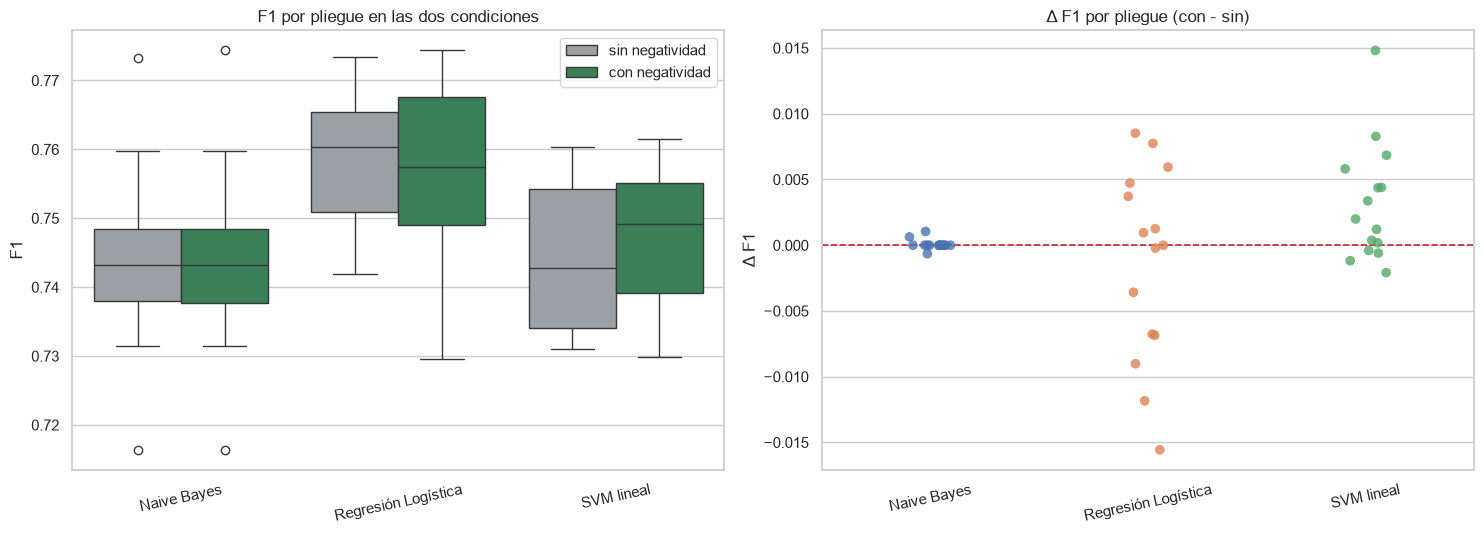

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

largo = pd.concat([
    detalle_base.assign(condicion='sin negatividad'),
    detalle_neg.assign(condicion='con negatividad'),
])
sns.boxplot(data=largo, x='modelo', y='f1', hue='condicion', ax=axes[0],
            palette=['#9aa0a6', '#2e8b57'])
axes[0].set_title('F1 por pliegue en las dos condiciones')
axes[0].set_xlabel('')
axes[0].set_ylabel('F1')
axes[0].tick_params(axis='x', rotation=12)
axes[0].legend(title='')

sns.stripplot(data=emparejado, x='modelo', y='diferencia', ax=axes[1],
              hue='modelo', palette='deep', legend=False, size=7, alpha=0.8)
axes[1].axhline(0, color='#c1272d', linewidth=1.2, linestyle='--')
axes[1].set_title('Δ F1 por pliegue (con - sin)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Δ F1')
axes[1].tick_params(axis='x', rotation=12)

plt.tight_layout()
plt.savefig(config.FIGURAS / 'efecto_negatividad.png', dpi=150, bbox_inches='tight')
plt.show()

### Lo que dice la validación cruzada

| Modelo | F1 sin | F1 con | Δ F1 medio | Pliegues que mejoran | p (t pareada) |
|---|---|---|---|---|---|
| Naive Bayes | 0.7445 ± 0.0133 | 0.7445 ± 0.0135 | +0.00007 | 2/15 | 0.474 |
| Regresión Logística | 0.7581 ± 0.0093 | 0.7567 ± 0.0126 | **-0.00140** | 8/15 | 0.471 |
| SVM lineal | 0.7442 ± 0.0102 | 0.7473 ± 0.0097 | +0.00316 | 11/15 | **0.016** |

Sobre quince pliegues el cuadro se aclara y desmiente en parte a la partición fija. **En la
regresión logística la variable no ayuda: perjudica**, en promedio, aunque la diferencia no
alcanza significancia. En Naive Bayes el efecto es cero a la cuarta cifra decimal. Sólo el SVM
lineal mejora de forma estadísticamente detectable, en 11 de 15 pliegues y con p = 0.016.

Conviene sin embargo mirar la magnitud de esa única mejora real: **+0.00316 de F1**, tres
milésimas. Es una mejora que existe pero que no cambia ninguna decisión práctica, y que además
deja al SVM (0.7473) por debajo de donde ya estaba la regresión logística sin la variable
(0.7581).

**Un hallazgo colateral, y no menor.** Las medias de esta tabla reordenan a los modelos respecto
del ejercicio 6. Sobre la partición fija ganaba Naive Bayes con F1 de 0.7734; sobre quince
pliegues gana la **regresión logística, 0.7581 contra 0.7445**, una ventaja de 1.4 puntos que
supera con holgura las desviaciones de ambos (0.009 y 0.013). La elección de Naive Bayes como
mejor modelo descansaba en una sola partición que le resultó favorable. Se retoma al cierre.

## 10.4 ¿Y si se añade todo el bloque de sentimiento?

Quizá la negatividad sola resuma demasiado. Se prueba a entregarle al modelo las seis
puntuaciones disponibles —las tres proporciones de VADER, la compuesta, y la polaridad y
subjetividad de TextBlob— por si el problema fuera de resumen y no de contenido.

In [7]:
BLOQUE = ['vader_neg', 'vader_neu', 'vader_pos', 'negatividad',
          'tb_polaridad', 'tb_subjetividad']

# La polaridad de TextBlob es negativa en parte del rango; MinMaxScaler la
# devuelve a [0, 1], que es lo que exige Naive Bayes multinomial.
bloque_completo = mod.evaluar(df, BLOQUE).set_index('modelo')

todo = pd.concat({
    'sin sentimiento': base['f1'],
    'sólo negatividad': con_neg['f1'],
    'bloque completo': bloque_completo['f1'],
}, axis=1)
print('F1 sobre la partición fija:')
print(todo.round(4).to_string())

F1 sobre la partición fija:
                     sin sentimiento  sólo negatividad  bloque completo
modelo                                                                 
Naive Bayes                   0.7734            0.7734           0.7675
Regresión Logística           0.7731            0.7756           0.7801
SVM lineal                    0.7590            0.7600           0.7603


### El bloque completo de sentimiento

| Modelo | Sin sentimiento | Sólo negatividad | Bloque completo |
|---|---|---|---|
| Naive Bayes | 0.7734 | 0.7734 | **0.7675** |
| Regresión Logística | 0.7731 | 0.7756 | 0.7801 |
| SVM lineal | 0.7590 | 0.7600 | 0.7603 |

Entregar las seis puntuaciones en lugar de una sola tampoco cambia el panorama. La regresión
logística gana siete milésimas y Naive Bayes **empeora** seis, que es el comportamiento
esperable de un modelo que supone independencia entre características cuando se le entregan seis
variables fuertemente correlacionadas entre sí —las tres proporciones de VADER suman uno por
construcción, y la compuesta se deriva de ellas.

El problema, entonces, no era que la negatividad resumiera demasiado.

## 10.5 Prueba pareada sobre las predicciones del mejor modelo

La comparación definitiva se hace sobre los mismos tweets de validación, contando en cuántos
casos un modelo acierta y el otro falla. La prueba de McNemar sólo mira esos casos
discordantes, que son los únicos que informan sobre cuál modelo es mejor.

In [8]:
mejor = mod.resumen_cruzada(detalle_base).loc[0, 'modelo']
print(f'Mejor modelo del ejercicio 6 según F1 en validación cruzada: {mejor}\n')

sin = mod.crear_pipeline(mod.clasificadores()[mejor])
sin.fit(entrena[mod.TEXTO], entrena['target'])
pred_sin = sin.predict(valida[mod.TEXTO])

con = mod.crear_pipeline_mixto(mod.clasificadores()[mejor], ['negatividad'])
con.fit(entrena[[mod.TEXTO, 'negatividad']], entrena['target'])
pred_con = con.predict(valida[[mod.TEXTO, 'negatividad']])

acierta_sin = pred_sin == valida['target'].to_numpy()
acierta_con = pred_con == valida['target'].to_numpy()

n01 = int((~acierta_sin & acierta_con).sum())   # arregla la negatividad
n10 = int((acierta_sin & ~acierta_con).sum())   # rompe la negatividad
print(f'Tweets que el modelo con negatividad arregla : {n01}')
print(f'Tweets que el modelo con negatividad rompe   : {n10}')
print(f'Tweets en los que ambos coinciden            : {len(valida) - n01 - n10}')

if n01 + n10 > 0:
    prueba = stats.binomtest(n01, n01 + n10, 0.5)
    print(f'\nMcNemar exacta sobre {n01 + n10} discordantes: p = {prueba.pvalue:.4f}')
print(f"\nF1 sin negatividad: {f1_score(valida['target'], pred_sin):.4f}")
print(f"F1 con negatividad: {f1_score(valida['target'], pred_con):.4f}")

Mejor modelo del ejercicio 6 según F1 en validación cruzada: Regresión Logística

Tweets que el modelo con negatividad arregla : 30
Tweets que el modelo con negatividad rompe   : 26
Tweets en los que ambos coinciden            : 1467

McNemar exacta sobre 56 discordantes: p = 0.6889

F1 sin negatividad: 0.7731
F1 con negatividad: 0.7756


## Respuesta al ejercicio 10

**¿La inclusión de la variable de negatividad mejoró los resultados del modelo de
clasificación? No de manera que importe.** Las cuatro mediciones coinciden:

| Evidencia | Resultado |
|---|---|
| La variable sola | accuracy 0.60 contra 0.5706 de la clase mayoritaria |
| Partición fija 80/20 | Δ F1 entre 0.0000 y +0.0025 |
| Validación cruzada, 15 pliegues | Δ F1 entre -0.0014 y +0.0032; sólo el SVM con p < 0.05 |
| McNemar sobre el mejor modelo | arregla 30 tweets, rompe 26, **p = 0.689** |

La prueba de McNemar es la más directa de las cuatro: sobre los mismos 1,523 tweets de
validación, añadir la negatividad **arregla 30 clasificaciones y rompe 26**. En 1,467 de 1,523
tweets los dos modelos dicen lo mismo. Una diferencia de 30 contra 26 es indistinguible de
lanzar una moneda 56 veces.

**Y en qué medida.** Si hay que dar una cifra, es **+0.0025 de F1** en la partición fija con el
modelo mejor, equivalente a unos cuatro tweets de 1,523, y **-0.0014** cuando se promedia sobre
quince particiones. La mejora no sobrevive al cambio de partición.

### Por qué no mejora

La explicación estaba en el cuaderno 08 y conviene recuperarla, porque el resultado no es una
casualidad de este conjunto. Las palabras que más contribuyen a la negatividad en este corpus
son `fire`, `emergency`, `disaster`, `crash`, `suicide`, `bomb`, `killed`, `dead`, `attack`,
`war`. **Son el vocabulario de desastre.**

El TF-IDF del ejercicio 6 ya usa cada una de esas palabras como predictora independiente, con un
peso aprendido de estos datos y de esta tarea. La variable de negatividad toma esas mismas
palabras y las promedia con pesos fijos, traídos de un léxico calibrado para otra cosa —medir
tono— y luego comprime el resultado en un solo número.

Es decir: no aporta información nueva, sino **una versión comprimida y con pérdida de
información que el modelo ya tenía en mejor forma**. Que la mejora sea nula no es un fallo del
análisis de sentimiento, es la consecuencia de que las dos representaciones se alimenten del
mismo vocabulario.

Cabría esperar que la variable sí aportara si el clasificador no viera el texto, o si la tarea
fuera otra —distinguir el tono de la cobertura periodística de un desastre, por ejemplo— donde
la polaridad no fuera un sinónimo del tema.

## 10.6 Modelo final recomendado

De todo lo anterior salen dos decisiones. La primera es **no incluir la variable de
negatividad**: no mejora, y añade al modelo una dependencia de un léxico externo a cambio de
nada. La segunda es **cambiar el mejor modelo de Naive Bayes a regresión logística**, porque la
ventaja de aquél existía sólo en la partición con semilla 42 y se invierte al promediar sobre
quince.

La función siguiente es la del ejercicio 7 con esas dos correcciones: recibe un tweet sin
preprocesar, le aplica exactamente la limpieza del ejercicio 3 y devuelve la clase junto con la
probabilidad estimada.

In [9]:
from src import texto as txt

final = mod.crear_pipeline(mod.clasificadores()['Regresión Logística'])
final.fit(df[mod.TEXTO], df['target'])


def clasificar_tweet(tweet):
    """Clasifica un tweet sin preprocesar como desastre real o no."""
    limpio = txt.limpieza_clasificacion(tweet)
    clase = int(final.predict([limpio])[0])
    probabilidad = float(final.predict_proba([limpio])[0, 1])
    return {
        'tweet': tweet,
        'texto_procesado': limpio,
        'clasificacion': 'desastre real' if clase else 'no desastre',
        'clase': clase,
        'probabilidad_desastre': round(probabilidad, 4),
    }


ejemplos = [
    'Massive earthquake destroys buildings and rescue teams are searching for survivors',
    'I had an amazing day at the beach with my friends',
    'Forest fire near La Ronge Sask. Canada',
    'This new album is absolute fire :) I am obsessed',
    'BREAKING: 13 dead after suicide bomber targets mosque http://t.co/abc123',
]
for ejemplo in ejemplos:
    salida = clasificar_tweet(ejemplo)
    print(f"[{salida['clasificacion']:>13}] p={salida['probabilidad_desastre']:.4f}  {ejemplo}")

[desastre real] p=0.9065  Massive earthquake destroys buildings and rescue teams are searching for survivors
[  no desastre] p=0.1008  I had an amazing day at the beach with my friends
[desastre real] p=0.9281  Forest fire near La Ronge Sask. Canada
[  no desastre] p=0.2223  This new album is absolute fire :) I am obsessed
[desastre real] p=0.9010  BREAKING: 13 dead after suicide bomber targets mosque http://t.co/abc123
